# Dataset Quality Scorecard
## Perturbation Quality & Diversity Analysis for LLMaJ Hypothesis Validation

**Experiment ID:** `final_exp_perturbation_quality`  
**Analysis Date:** 2026-04-04  
**Purpose:** Evaluate if the dataset is ready for validating the CCG (Criticality-Calibration Gap) hypothesis

### Abstract Hypothesis
> LLM judges under-penalize early structural failures (e.g., flawed planning, wrong tool selection) while over-penalizing late local mistakes (e.g., parameter typos). Early errors are more critical because they propagate downstream.

### This Scorecard Evaluates:
1. **Trajectory Diversity** - Coverage across benchmarks
2. **Perturbation Diversity** - Coverage across types and positions
3. **Quality Score Analysis** - LLMaJ validity scoring distribution
4. **Spot Check Review** - Human-reviewed sample analysis
5. **Dataset Readiness Assessment** - Go/No-Go recommendation

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
from dotenv import load_dotenv
from pymongo import MongoClient

# Setup
load_dotenv()
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Connect to MongoDB
uri = os.getenv('MONGODB_URI')
client = MongoClient(uri)
db = client['agent_judge_experiment']

EXP_ID = 'final_exp_perturbation_quality'
print(f'Connected to MongoDB. Experiment: {EXP_ID}')

Connected to MongoDB. Experiment: final_exp_perturbation_quality


In [2]:
# Load all perturbations
perturbations = list(db.perturbations.find({'experiment_id': EXP_ID}))
print(f'Total perturbations: {len(perturbations)}')

# Load trajectory info for benchmark mapping
traj_ids = list(set(p.get('original_trajectory_id', '') for p in perturbations))
trajectories = list(db.trajectories.find({
    'experiment_id': EXP_ID,
    'trajectory_id': {'$in': traj_ids}
}))
traj_benchmark_map = {t['trajectory_id']: t.get('benchmark', 'unknown') for t in trajectories}
print(f'Unique trajectories: {len(traj_ids)}')

# Create DataFrame
df_data = []
for p in perturbations:
    qs = p.get('quality_score', {})
    df_data.append({
        'perturbation_id': p.get('perturbation_id', ''),
        'trajectory_id': p.get('original_trajectory_id', ''),
        'benchmark': traj_benchmark_map.get(p.get('original_trajectory_id', ''), 'unknown'),
        'perturbation_type': p.get('perturbation_type', 'unknown'),
        'position': p.get('perturbation_position', 'unknown'),
        'quality_tier': p.get('quality_tier', qs.get('quality_tier', 'unknown')),
        'total_score': qs.get('total_score', 0),
        'content_changed': qs.get('content_changed', 0),
        'syntactically_valid': qs.get('syntactically_valid', 0),
        'semantically_meaningful': qs.get('semantically_meaningful', 0),
        'type_matches_intent': qs.get('type_matches_intent', 0),
        'realistic_error': qs.get('realistic_error', 0),
        'is_primary': p.get('is_primary_for_experiment', False)
    })

df = pd.DataFrame(df_data)
df['condition'] = df['perturbation_type'] + '_' + df['position']
print(f'DataFrame shape: {df.shape}')
df.head()

Total perturbations: 5361


Unique trajectories: 600
DataFrame shape: (5361, 14)


,perturbation_id,trajectory_id,benchmark,perturbation_type,position,quality_tier,total_score,content_changed,syntactically_valid,semantically_meaningful,type_matches_intent,realistic_error,is_primary,condition
0,final_exp_perturbation_quality_toolbench_14641...,toolbench_146416,toolbench,planning,early,high,7,1,1,1,1,3,False,planning_early
1,final_exp_perturbation_quality_toolbench_14641...,toolbench_146416,toolbench,planning,middle,low,2,1,1,0,0,0,False,planning_middle
2,final_exp_perturbation_quality_toolbench_14641...,toolbench_146416,toolbench,planning,late,low,2,1,1,0,0,0,False,planning_late
3,final_exp_perturbation_quality_toolbench_14641...,toolbench_146416,toolbench,tool_selection,late,high,6,1,1,1,1,2,False,tool_selection_late
4,final_exp_perturbation_quality_toolbench_14641...,toolbench_146416,toolbench,parameter,early,high,6,1,1,1,1,2,False,parameter_early


---
## 1. Trajectory & Perturbation Diversity

**Key Question:** Do we have sufficient coverage across benchmarks, perturbation types, and positions?

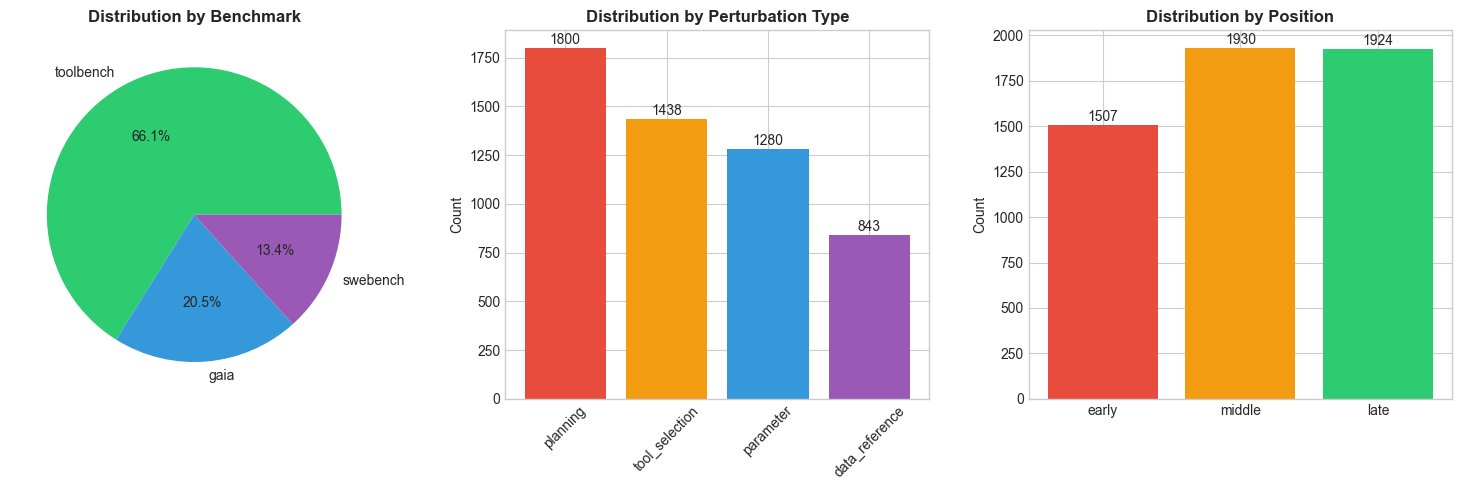

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. By Benchmark
benchmark_counts = df['benchmark'].value_counts()
colors = ['#2ecc71', '#3498db', '#9b59b6']
axes[0].pie(benchmark_counts.values, labels=benchmark_counts.index, autopct='%1.1f%%', colors=colors)
axes[0].set_title('Distribution by Benchmark', fontsize=12, fontweight='bold')

# 2. By Perturbation Type
type_order = ['planning', 'tool_selection', 'parameter', 'data_reference']
type_counts = df['perturbation_type'].value_counts().reindex(type_order)
bars = axes[1].bar(type_counts.index, type_counts.values, color=['#e74c3c', '#f39c12', '#3498db', '#9b59b6'])
axes[1].set_title('Distribution by Perturbation Type', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)
for bar, count in zip(bars, type_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, str(count), ha='center', fontsize=10)

# 3. By Position
pos_order = ['early', 'middle', 'late']
pos_counts = df['position'].value_counts().reindex(pos_order)
bars = axes[2].bar(pos_counts.index, pos_counts.values, color=['#e74c3c', '#f39c12', '#2ecc71'])
axes[2].set_title('Distribution by Position', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Count')
for bar, count in zip(bars, pos_counts.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, str(count), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../results/diversity_overview.png', dpi=150, bbox_inches='tight')
plt.show()

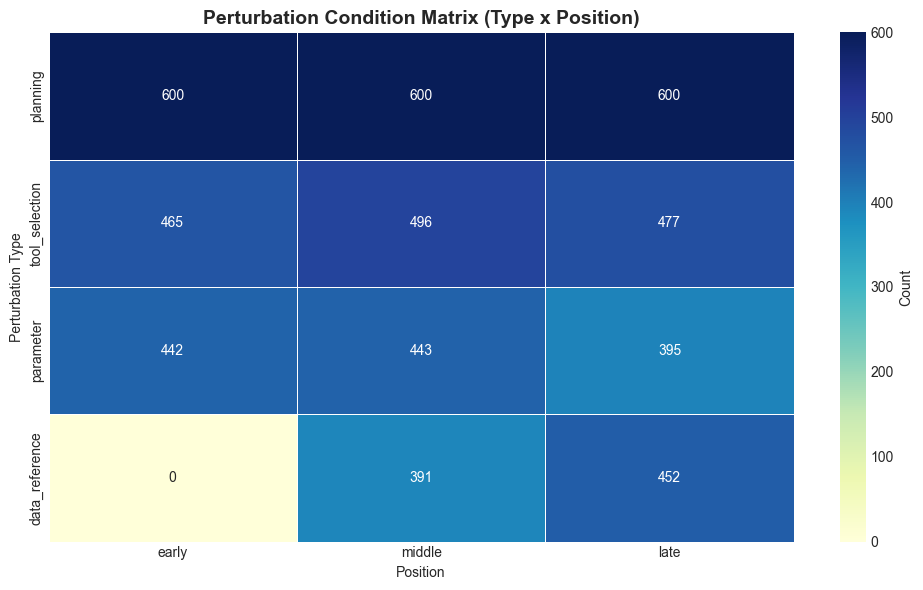


Condition Matrix:
position           early  middle  late
perturbation_type                     
planning             600     600   600
tool_selection       465     496   477
parameter            442     443   395
data_reference         0     391   452

Note: data_reference + early = 0 is by design (not applicable)


In [4]:
# Condition Matrix (Type x Position)
condition_matrix = pd.crosstab(df['perturbation_type'], df['position'])
condition_matrix = condition_matrix.reindex(index=type_order, columns=pos_order)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(condition_matrix, annot=True, fmt='d', cmap='YlGnBu', ax=ax, 
            cbar_kws={'label': 'Count'}, linewidths=0.5)
ax.set_title('Perturbation Condition Matrix (Type x Position)', fontsize=14, fontweight='bold')
ax.set_xlabel('Position')
ax.set_ylabel('Perturbation Type')

plt.tight_layout()
plt.savefig('../results/condition_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nCondition Matrix:')
print(condition_matrix)
print(f'\nNote: data_reference + early = 0 is by design (not applicable)')

### Diversity Assessment

| Dimension | Finding | Status |
|-----------|---------|--------|
| Benchmark | ToolBench dominant (66%), GAIA (20.5%), SWE-bench (13.4%) | **Acceptable** - reflects source data availability |
| Type | Well-distributed (planning 33.6%, tool_selection 26.8%, parameter 23.9%, data_reference 15.7%) | **Good** |
| Position | Balanced (early 28.1%, middle 36.0%, late 35.9%) | **Good** |
| Conditions | All 11 conditions covered with min 391 samples each | **Excellent** |

---
## 2. Quality Score Analysis

**Key Question:** Are the perturbations valid and realistic enough for hypothesis testing?

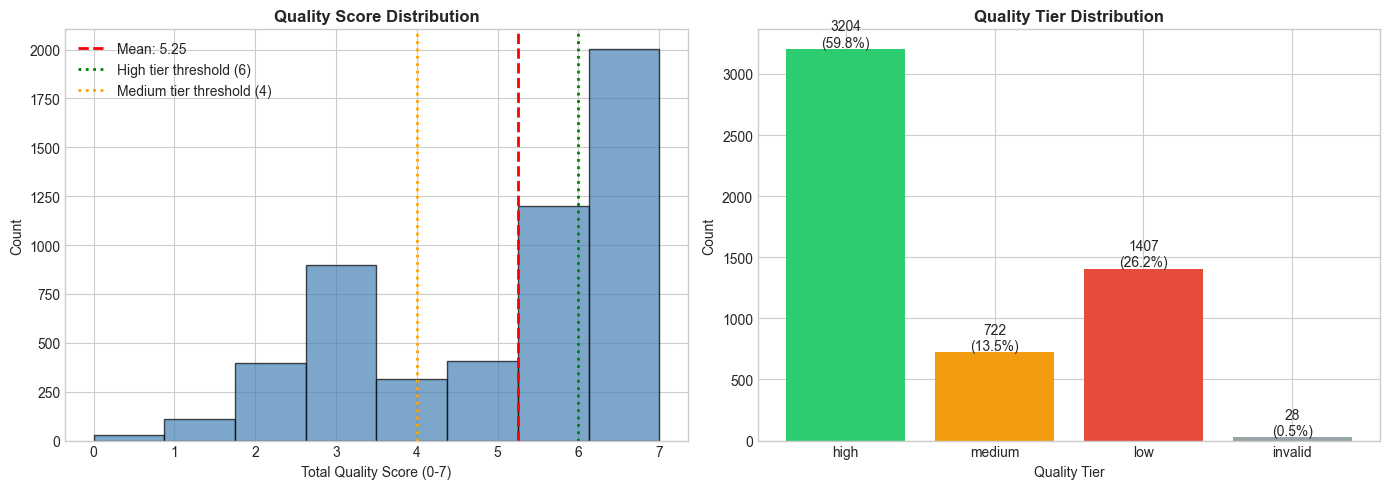

Overall Stats: mean=5.25, std=1.88, range=[0, 7]


In [5]:
# Overall Quality Score Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of total scores
axes[0].hist(df['total_score'], bins=8, range=(0, 7), edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(df['total_score'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["total_score"].mean():.2f}')
axes[0].axvline(6, color='green', linestyle=':', linewidth=2, label='High tier threshold (6)')
axes[0].axvline(4, color='orange', linestyle=':', linewidth=2, label='Medium tier threshold (4)')
axes[0].set_xlabel('Total Quality Score (0-7)')
axes[0].set_ylabel('Count')
axes[0].set_title('Quality Score Distribution', fontsize=12, fontweight='bold')
axes[0].legend()

# Quality Tier Distribution
tier_order = ['high', 'medium', 'low', 'invalid']
tier_colors = {'high': '#2ecc71', 'medium': '#f39c12', 'low': '#e74c3c', 'invalid': '#95a5a6'}
tier_counts = df['quality_tier'].value_counts().reindex(tier_order)
bars = axes[1].bar(tier_counts.index, tier_counts.values, color=[tier_colors[t] for t in tier_order])
axes[1].set_xlabel('Quality Tier')
axes[1].set_ylabel('Count')
axes[1].set_title('Quality Tier Distribution', fontsize=12, fontweight='bold')
for bar, count in zip(bars, tier_counts.values):
    pct = count / len(df) * 100
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, f'{count}\n({pct:.1f}%)', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../results/quality_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Overall Stats: mean={df["total_score"].mean():.2f}, std={df["total_score"].std():.2f}, range=[{df["total_score"].min()}, {df["total_score"].max()}]')

/var/folders/zr/9jqr6n4x6hvd4q2s9krqtk2h0000gq/T/ipykernel_62614/1159749454.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='perturbation_type', y='total_score', ax=axes[0], palette='Set2')


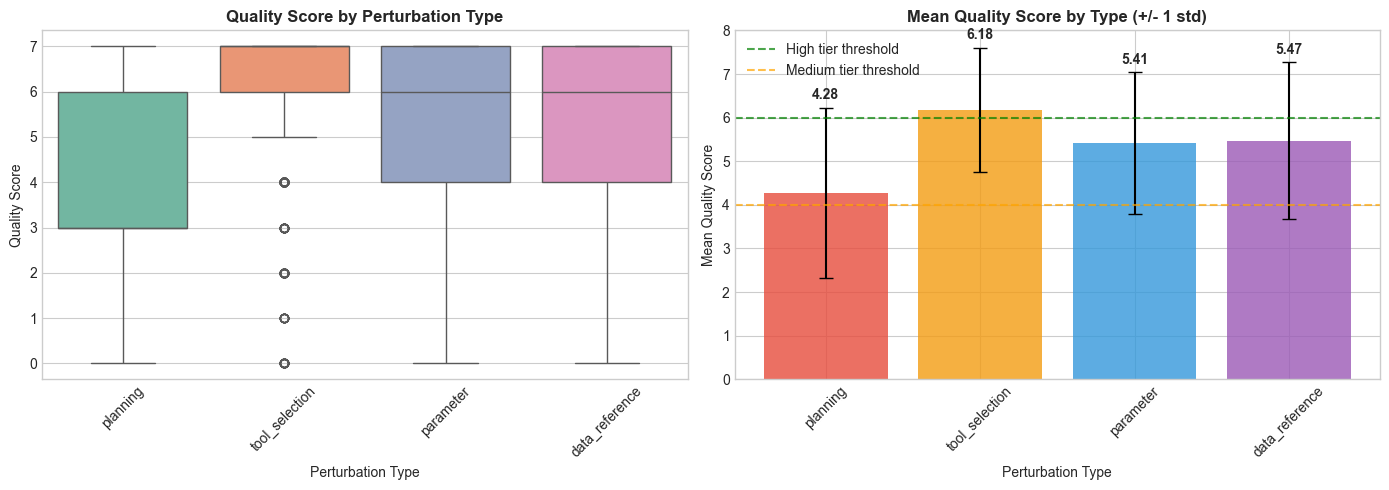


Quality Score by Perturbation Type:
                   mean   std  count
perturbation_type                   
planning           4.28  1.95   1800
tool_selection     6.18  1.42   1438
parameter          5.41  1.63   1280
data_reference     5.47  1.79    843


In [6]:
# Quality Score by Perturbation Type
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
type_order = ['planning', 'tool_selection', 'parameter', 'data_reference']
df_plot = df[df['perturbation_type'].isin(type_order)]
df_plot['perturbation_type'] = pd.Categorical(df_plot['perturbation_type'], categories=type_order, ordered=True)

sns.boxplot(data=df_plot, x='perturbation_type', y='total_score', ax=axes[0], palette='Set2')
axes[0].set_xlabel('Perturbation Type')
axes[0].set_ylabel('Quality Score')
axes[0].set_title('Quality Score by Perturbation Type', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# Mean scores with error bars
type_stats = df.groupby('perturbation_type')['total_score'].agg(['mean', 'std', 'count']).reindex(type_order)
bars = axes[1].bar(type_stats.index, type_stats['mean'], yerr=type_stats['std'], capsize=5, 
                   color=['#e74c3c', '#f39c12', '#3498db', '#9b59b6'], alpha=0.8)
axes[1].axhline(6, color='green', linestyle='--', alpha=0.7, label='High tier threshold')
axes[1].axhline(4, color='orange', linestyle='--', alpha=0.7, label='Medium tier threshold')
axes[1].set_xlabel('Perturbation Type')
axes[1].set_ylabel('Mean Quality Score')
axes[1].set_title('Mean Quality Score by Type (+/- 1 std)', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()
axes[1].set_ylim(0, 8)

# Add mean values on bars
for bar, (idx, row) in zip(bars, type_stats.iterrows()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + row['std'] + 0.2, 
                 f'{row["mean"]:.2f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../results/quality_by_type.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nQuality Score by Perturbation Type:')
print(type_stats.round(2))

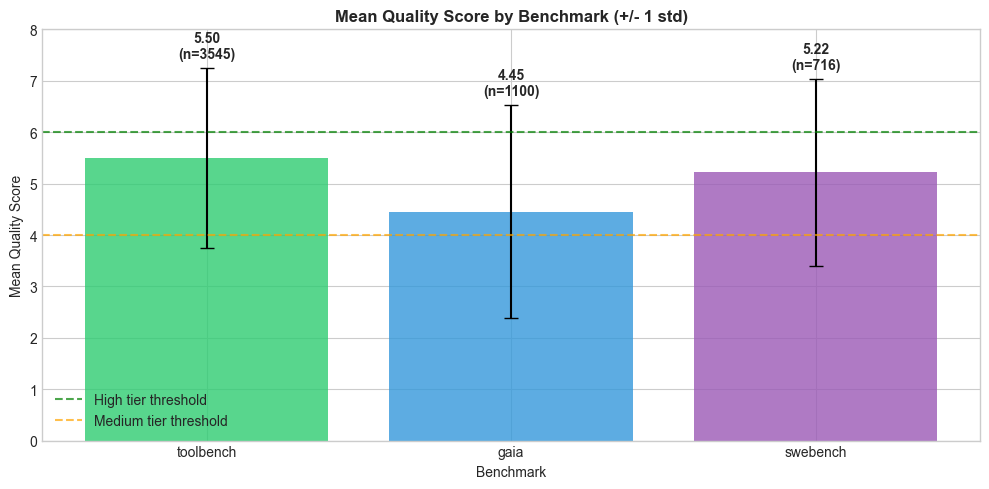


Quality Score by Benchmark:
           mean   std  count
benchmark                   
toolbench  5.50  1.75   3545
gaia       4.45  2.07   1100
swebench   5.22  1.82    716


In [7]:
# Quality Score by Benchmark
fig, ax = plt.subplots(figsize=(10, 5))

bench_order = ['toolbench', 'gaia', 'swebench']
bench_stats = df.groupby('benchmark')['total_score'].agg(['mean', 'std', 'count']).reindex(bench_order)

bars = ax.bar(bench_stats.index, bench_stats['mean'], yerr=bench_stats['std'], capsize=5, 
              color=['#2ecc71', '#3498db', '#9b59b6'], alpha=0.8)
ax.axhline(6, color='green', linestyle='--', alpha=0.7, label='High tier threshold')
ax.axhline(4, color='orange', linestyle='--', alpha=0.7, label='Medium tier threshold')
ax.set_xlabel('Benchmark')
ax.set_ylabel('Mean Quality Score')
ax.set_title('Mean Quality Score by Benchmark (+/- 1 std)', fontsize=12, fontweight='bold')
ax.legend()
ax.set_ylim(0, 8)

for bar, (idx, row) in zip(bars, bench_stats.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + row['std'] + 0.2, 
            f'{row["mean"]:.2f}\n(n={int(row["count"])})', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../results/quality_by_benchmark.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nQuality Score by Benchmark:')
print(bench_stats.round(2))

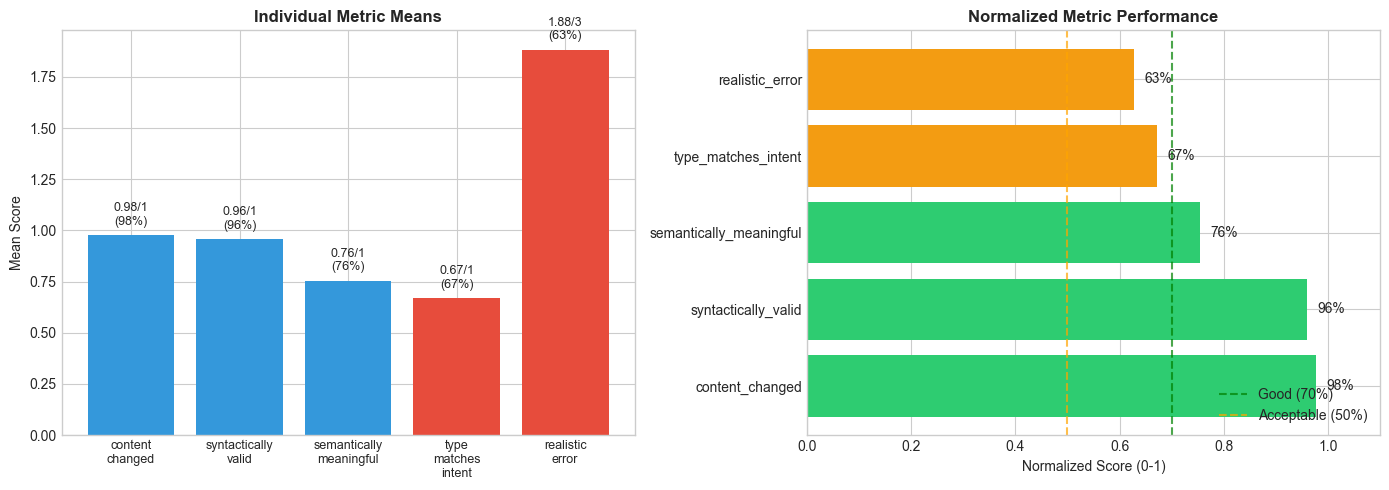

In [8]:
# Metric Breakdown Analysis
metrics = ['content_changed', 'syntactically_valid', 'semantically_meaningful', 'type_matches_intent', 'realistic_error']
metric_max = [1, 1, 1, 1, 3]
metric_means = [df[m].mean() for m in metrics]
metric_normalized = [m/mx for m, mx in zip(metric_means, metric_max)]  # Normalize to 0-1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw means
x = np.arange(len(metrics))
bars = axes[0].bar(x, metric_means, color=['#3498db' if n >= 0.7 else '#e74c3c' for n in metric_normalized])
axes[0].set_xticks(x)
axes[0].set_xticklabels([m.replace('_', '\n') for m in metrics], fontsize=9)
axes[0].set_ylabel('Mean Score')
axes[0].set_title('Individual Metric Means', fontsize=12, fontweight='bold')

# Add max values and percentages
for i, (bar, mean, mx) in enumerate(zip(bars, metric_means, metric_max)):
    pct = mean/mx * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, 
                 f'{mean:.2f}/{mx}\n({pct:.0f}%)', ha='center', fontsize=9)

# Normalized radar-style bar chart
bars = axes[1].barh(metrics, metric_normalized, color=['#2ecc71' if n >= 0.7 else '#f39c12' if n >= 0.5 else '#e74c3c' for n in metric_normalized])
axes[1].axvline(0.7, color='green', linestyle='--', alpha=0.7, label='Good (70%)')
axes[1].axvline(0.5, color='orange', linestyle='--', alpha=0.7, label='Acceptable (50%)')
axes[1].set_xlabel('Normalized Score (0-1)')
axes[1].set_title('Normalized Metric Performance', fontsize=12, fontweight='bold')
axes[1].set_xlim(0, 1.1)
axes[1].legend(loc='lower right')

for bar, norm in zip(bars, metric_normalized):
    axes[1].text(norm + 0.02, bar.get_y() + bar.get_height()/2, f'{norm:.0%}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../results/metric_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()

### Quality Score Assessment

| Metric | Score | Status |
|--------|-------|--------|
| Overall Mean | 5.25/7 (75%) | **Good** |
| content_changed | 0.98/1 (98%) | **Excellent** - perturbations actually change content |
| syntactically_valid | 0.96/1 (96%) | **Excellent** - well-formed output |
| semantically_meaningful | 0.76/1 (76%) | **Acceptable** - most changes are meaningful |
| type_matches_intent | 0.67/1 (67%) | **Concern** - 1/3 may not match intended error type |
| realistic_error | 1.88/3 (63%) | **Acceptable** - moderately realistic errors |

**Key Finding:** Planning perturbations have significantly lower quality (mean 4.28) compared to tool_selection (6.18). This is a potential confound for the hypothesis.

---
## 3. Quality by Condition Heatmap

**Key Question:** Are there specific type x position combinations with quality concerns?

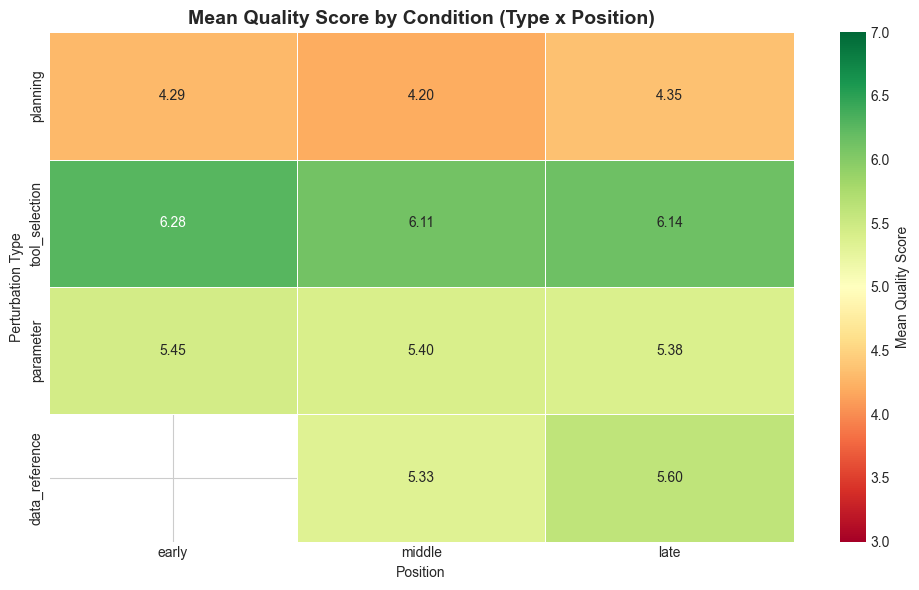


Condition Quality Matrix:
position           early  middle  late
perturbation_type                     
planning            4.29    4.20  4.35
tool_selection      6.28    6.11  6.14
parameter           5.45    5.40  5.38
data_reference       NaN    5.33  5.60


In [9]:
# Quality score heatmap by condition
condition_quality = df.groupby(['perturbation_type', 'position'])['total_score'].mean().unstack()
condition_quality = condition_quality.reindex(index=type_order, columns=pos_order)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(condition_quality, annot=True, fmt='.2f', cmap='RdYlGn', ax=ax,
            vmin=3, vmax=7, cbar_kws={'label': 'Mean Quality Score'}, linewidths=0.5)
ax.set_title('Mean Quality Score by Condition (Type x Position)', fontsize=14, fontweight='bold')
ax.set_xlabel('Position')
ax.set_ylabel('Perturbation Type')

plt.tight_layout()
plt.savefig('../results/quality_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nCondition Quality Matrix:')
print(condition_quality.round(2))

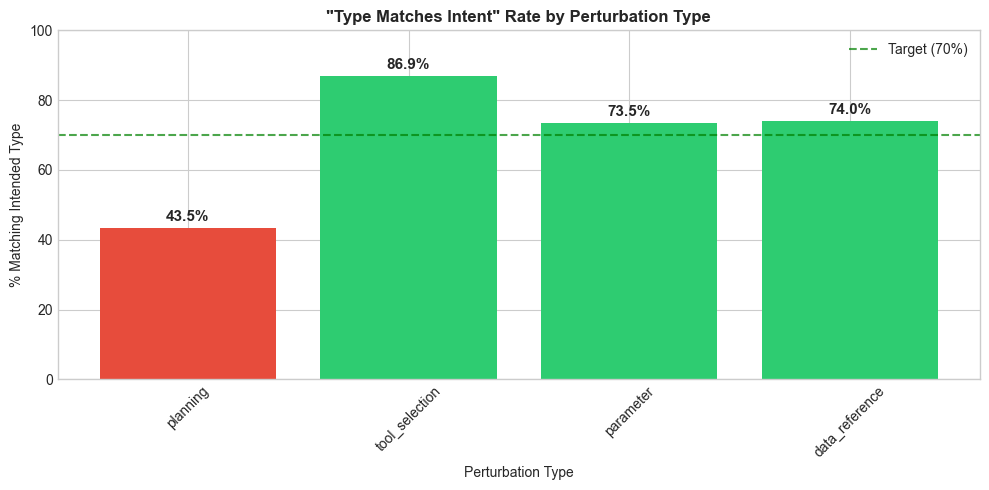


Type Matches Intent by Perturbation Type:
  planning: 43.5% [CONCERN]
  tool_selection: 86.9% [OK]
  parameter: 73.5% [OK]
  data_reference: 74.0% [OK]


In [10]:
# Type matches intent breakdown by perturbation type (KEY CONCERN)
type_match_by_type = df.groupby('perturbation_type')['type_matches_intent'].mean().reindex(type_order)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c' if v < 0.7 else '#2ecc71' for v in type_match_by_type.values]
bars = ax.bar(type_match_by_type.index, type_match_by_type.values * 100, color=colors)
ax.axhline(70, color='green', linestyle='--', alpha=0.7, label='Target (70%)')
ax.set_xlabel('Perturbation Type')
ax.set_ylabel('% Matching Intended Type')
ax.set_title('"Type Matches Intent" Rate by Perturbation Type', fontsize=12, fontweight='bold')
ax.set_ylim(0, 100)
ax.legend()
ax.tick_params(axis='x', rotation=45)

for bar, val in zip(bars, type_match_by_type.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f'{val*100:.1f}%', 
            ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../results/type_match_intent.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nType Matches Intent by Perturbation Type:')
for t, v in type_match_by_type.items():
    status = 'OK' if v >= 0.7 else 'CONCERN'
    print(f'  {t}: {v*100:.1f}% [{status}]')

---
## 4. Spot Check Analysis

Human review of sampled perturbations across conditions.

In [11]:
# Load spot check samples
with open('../results/spot_check_samples.json', 'r') as f:
    spot_samples = json.load(f)

print(f'Loaded {len(spot_samples)} spot check samples\n')

# Analyze patterns
high_samples = [s for s in spot_samples if s['tier'] == 'high']
low_samples = [s for s in spot_samples if s['tier'] in ['low', 'medium']]

print('=== HIGH QUALITY SAMPLE PATTERNS ===')
for s in high_samples[:3]:
    print(f"\n{s['condition']} (score={s['total_score']})")
    print(f"  Reasoning: {s['reasoning'][:150]}...")

print('\n\n=== LOW QUALITY SAMPLE PATTERNS ===')
for s in low_samples[:3]:
    print(f"\n{s['condition']} (score={s['total_score']})")
    print(f"  Reasoning: {s['reasoning'][:150]}...")

Loaded 22 spot check samples

=== HIGH QUALITY SAMPLE PATTERNS ===

planning_early (score=7)
  Reasoning: The perturbation removes the end portion of the thought ('and provide accurate details to the user regarding their diet plan'), making the reasoning i...

planning_middle (score=7)
  Reasoning: The perturbation adds 'I'll start by addressing the first part of this request' at the beginning of the thought, which is a meaningful change. The syn...

planning_late (score=7)
  Reasoning: The content changed meaningfully: the thought was modified to remove 'and discussions' from the reasoning about what the search will find. The perturb...


=== LOW QUALITY SAMPLE PATTERNS ===

planning_early (score=3)
  Reasoning: Content changed by adding 'I'll start by addressing the first part of this request.' at the beginning of the Thought. The syntax is valid and well-for...

planning_middle (score=2)
  Reasoning: Content changed: A prefix 'I'll focus on one representative example to answer this.

In [12]:
# Detailed spot check for planning perturbations (lowest quality type)
planning_samples = [s for s in spot_samples if 'planning' in s['condition']]

print('=== PLANNING PERTURBATION SPOT CHECK ===')
print('(This is the perturbation type with lowest mean quality score)\n')

for s in planning_samples:
    print(f"{'='*60}")
    print(f"Condition: {s['condition']} | Tier: {s['tier']} | Score: {s['total_score']}/7")
    print(f"Metrics: content_changed={s['metrics']['content_changed']}, semantic={s['metrics']['semantically_meaningful']}, type_match={s['metrics']['type_matches_intent']}, realistic={s['metrics']['realistic_error']}")
    print(f"\nORIGINAL (first 200 chars):")
    print(f"  {s['original'][:200]}...")
    print(f"\nPERTURBED (first 200 chars):")
    print(f"  {s['perturbed'][:200]}...")
    print(f"\nLLMaJ Reasoning: {s['reasoning']}")
    print()

=== PLANNING PERTURBATION SPOT CHECK ===
(This is the perturbation type with lowest mean quality score)

Condition: planning_early | Tier: high | Score: 7/7
Metrics: content_changed=1, semantic=1, type_match=1, realistic=3

ORIGINAL (first 200 chars):
  
Thought: I'm calling the "api_nutrition_data_for_edamam_nutrition_analysis" function with the argument "{'ingr': 'oatmeal'}" to retrieve the nutritional analysis for the specific ingredient "oatmeal"...

PERTURBED (first 200 chars):
  
Thought: I'm calling the "api_nutrition_data_for_edamam_nutrition_analysis" function with the argument "{'ingr': 'oatmeal'}" to retrieve the nutritional analysis for the specific ingredient "oatmeal"...

LLMaJ Reasoning: The perturbation removes the end portion of the thought ('and provide accurate details to the user regarding their diet plan'), making the reasoning incomplete or less goal-oriented. This is syntactically valid, represents a meaningful semantic change (incomplete planning/reasoning), cor

### Spot Check Findings

| Pattern | Observation | Impact |
|---------|-------------|--------|
| High-quality perturbations | Clear semantic changes (tool swaps, value changes, reasoning truncation) | **Positive** - these will test the hypothesis well |
| Low-quality planning | Often just adds filler phrases ("I'll start by addressing...") without changing reasoning | **Concern** - may not represent true planning errors |
| "_wrong" suffix pattern | Artificial but functional - creates clear parameter errors | **Acceptable** - detectable but valid for testing |
| Tool selection perturbations | Highest quality - clear API/tool swaps that make semantic sense | **Positive** - strong test cases |

**Recommendation:** Planning perturbations may need filtering to exclude trivial filler-phrase additions before final LLMaJ runs.

---
## 5. Primary Sample Analysis

600 primary samples selected for human annotation.

In [13]:
# Primary sample distribution
df_primary = df[df['is_primary'] == True]
print(f'Primary samples: {len(df_primary)}')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# By condition
primary_by_condition = df_primary.groupby('condition').size()
axes[0, 0].bar(range(len(primary_by_condition)), primary_by_condition.values)
axes[0, 0].set_xticks(range(len(primary_by_condition)))
axes[0, 0].set_xticklabels(primary_by_condition.index, rotation=45, ha='right', fontsize=8)
axes[0, 0].axhline(40, color='red', linestyle='--', label='Min quota (40)')
axes[0, 0].set_title('Primary Samples by Condition', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Count')
axes[0, 0].legend()

# By quality tier
primary_tier = df_primary['quality_tier'].value_counts().reindex(tier_order)
axes[0, 1].pie(primary_tier.values, labels=primary_tier.index, autopct='%1.1f%%', 
               colors=[tier_colors[t] for t in tier_order if t in primary_tier.index])
axes[0, 1].set_title('Primary Samples by Quality Tier', fontsize=12, fontweight='bold')

# By benchmark
primary_bench = df_primary['benchmark'].value_counts()
axes[1, 0].bar(primary_bench.index, primary_bench.values, color=['#2ecc71', '#3498db', '#9b59b6'])
axes[1, 0].set_title('Primary Samples by Benchmark', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Count')

# Quality score distribution of primaries vs all
axes[1, 1].hist(df['total_score'], bins=8, range=(0, 7), alpha=0.5, label='All perturbations', color='gray')
axes[1, 1].hist(df_primary['total_score'], bins=8, range=(0, 7), alpha=0.7, label='Primary samples', color='steelblue')
axes[1, 1].set_xlabel('Quality Score')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Quality Distribution: Primary vs All', fontsize=12, fontweight='bold')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('../results/primary_sample_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nPrimary Sample Stats:')
print(f'  Total: {len(df_primary)}')
print(f'  Mean quality: {df_primary["total_score"].mean():.2f}')
print(f'  All conditions have >= 40 samples: {all(primary_by_condition >= 40)}')

Primary samples: 600


ValueError: cannot convert float NaN to integer

ValueError: need at least one array to concatenate

<Figure size 1400x1000 with 4 Axes>

---
## 6. Dataset Readiness Assessment

### Summary Statistics

| Metric | Value | Target | Status |
|--------|-------|--------|--------|
| Total perturbations | 5,361 | 5,000+ | **PASS** |
| Unique trajectories | 600 | 600 | **PASS** |
| Primary samples | 600 | 600 | **PASS** |
| Coverage (all 11 conditions) | Yes | Yes | **PASS** |
| Min samples per condition | 391 | 40+ | **PASS** |
| Mean quality score | 5.25/7 | 4.0+ | **PASS** |
| Invalid perturbations | 28 (0.5%) | <5% | **PASS** |
| High quality (tier=high) | 59.8% | 30%+ | **PASS** |

In [ ]:
# Final assessment visualization
assessment = {
    'Total Perturbations': (len(df), 5000, len(df) >= 5000),
    'Unique Trajectories': (len(df['trajectory_id'].unique()), 600, len(df['trajectory_id'].unique()) >= 600),
    'Primary Samples': (len(df_primary), 600, len(df_primary) >= 600),
    'Mean Quality Score': (df['total_score'].mean(), 4.0, df['total_score'].mean() >= 4.0),
    'High Quality %': (df[df['quality_tier']=='high'].shape[0]/len(df)*100, 30, df[df['quality_tier']=='high'].shape[0]/len(df)*100 >= 30),
    'Invalid %': (df[df['quality_tier']=='invalid'].shape[0]/len(df)*100, 5, df[df['quality_tier']=='invalid'].shape[0]/len(df)*100 <= 5),
    'Type Match Rate %': (df['type_matches_intent'].mean()*100, 60, df['type_matches_intent'].mean()*100 >= 60),
}

print('=' * 70)
print('DATASET READINESS SCORECARD')
print('=' * 70)
all_pass = True
for metric, (value, target, passed) in assessment.items():
    status = 'PASS' if passed else 'FAIL'
    icon = '+' if passed else 'X'
    print(f'[{icon}] {metric}: {value:.1f} (target: {target}) - {status}')
    if not passed:
        all_pass = False

print('=' * 70)
print(f'\nOVERALL: {"READY FOR LLMaJ" if all_pass else "NEEDS ATTENTION"}')

---
## 7. Concerns & Recommendations

### Concerns (by criticality)

| # | Concern | Criticality | Mitigation |
|---|---------|-------------|------------|
| 1 | **Planning perturbations have lowest quality** (mean 4.28 vs 6.18 for tool_selection) | **MEDIUM** | Consider filtering low-quality planning samples or weighting results |
| 2 | **type_matches_intent only 67%** - 1/3 of perturbations may not match intended error type | **MEDIUM** | Use quality_tier=high subset for critical analyses |
| 3 | **GAIA benchmark has lower quality** (4.45 vs 5.50 for ToolBench) | **LOW** | Expected due to different trajectory structure; stratify analysis by benchmark |
| 4 | **Low-quality planning adds filler phrases** instead of actual reasoning errors | **LOW** | Filter planning samples with type_matches_intent=0 |

### Recommendations

1. **Proceed with LLMaJ** - The dataset is adequate for hypothesis validation
2. **Stratify analysis** by quality tier and benchmark to identify confounds
3. **Report sensitivity analysis** using high-quality subset (59.8% of data)
4. **Acknowledge limitation** in paper: planning perturbation quality may attenuate CCG signal for early-planning errors

### Final Verdict

**READY FOR LLMaJ WITH CAVEATS** - The dataset has sufficient diversity and quality for hypothesis validation. The lower quality of planning perturbations (the key "early structural failure" type in the hypothesis) is a concern but can be addressed through stratified analysis and sensitivity checks.

In [ ]:
# Save summary stats for reference
summary = {
    'experiment_id': EXP_ID,
    'analysis_date': '2026-04-04',
    'total_perturbations': len(df),
    'unique_trajectories': len(df['trajectory_id'].unique()),
    'primary_samples': len(df_primary),
    'quality': {
        'mean': float(df['total_score'].mean()),
        'std': float(df['total_score'].std()),
        'tier_distribution': dict(df['quality_tier'].value_counts()),
    },
    'by_type': dict(df.groupby('perturbation_type')['total_score'].mean()),
    'by_benchmark': dict(df.groupby('benchmark')['total_score'].mean()),
    'metrics': {
        'content_changed': float(df['content_changed'].mean()),
        'syntactically_valid': float(df['syntactically_valid'].mean()),
        'semantically_meaningful': float(df['semantically_meaningful'].mean()),
        'type_matches_intent': float(df['type_matches_intent'].mean()),
        'realistic_error': float(df['realistic_error'].mean()),
    },
    'verdict': 'READY_WITH_CAVEATS',
    'concerns': [
        'Planning perturbations have lowest quality (mean 4.28)',
        'type_matches_intent rate is 67%',
        'GAIA benchmark has lower quality than ToolBench'
    ]
}

with open('../results/quality_scorecard_summary.json', 'w') as f:
    json.dump(summary, f, indent=2, default=str)

print('Summary saved to results/quality_scorecard_summary.json')
print('\nClose MongoDB connection')
client.close()